#Mini-Project : Data Analysis for Marketing Strategy -->

Introduction

In this mini-project, we will perform data analysis to devise a marketing strategy based on various aspects like area analysis, customer analysis, product category analysis, and sales and profit time series.

👩‍🏫 👩🏿‍🏫 What You’ll learn

How to load and preprocess a dataset.
Techniques for area analysis to identify key markets.
Methods for customer analysis to determine high-value customers.
Strategies for product category analysis to identify top-performing products.
How to analyze sales and profit trends over time.
Application of the Pareto Principle to prioritize key drivers of sales and profit.

Dataset

The US Superstore Dataset contains the following attributes:

Row ID: Unique ID for each row.
Order ID: Unique Order ID for each Customer.
Order Date: Order Date of the product.
Ship Date: Shipping Date of the Product.
Ship Mode: Shipping Mode specified by the Customer.
Customer ID: Unique ID to identify each Customer.
Customer Name: Name of the Customer.
Segment: The segment where the Customer belongs.
Country: Country of residence of the Customer.
City: City of residence of the Customer.
State: State of residence of the Customer.
Postal Code: Postal Code of every Customer.
Region: Region where the Customer belongs.
Product ID: Unique ID of the Product.
Category: Category of the product ordered.
Sub-Category: Sub-Category of the product ordered.
Product Name: Name of the Product.
Sales: Sales of the Product.
Quantity: Quantity of the Product.
Discount: Discount provided.
Profit: Profit/Loss incurred.

Task

First load the dataset in a notebook and preprocess it. Then use visualisations to address the following questions:

Which states have the most sales?

What is the difference between New York and California in terms of sales and profit? (Compare the total sales and profit between New York and California.)

Who is an outstanding customer in New York?

Are there any differences among states in profitability?

The Pareto Principle, also known as the 80/20 rule, is a concept derived from the work of Italian economist Vilfredo Pareto. It states that roughly 80% of the effects come from 20% of the causes. For instance, identifying the top 20% of products that generate 80% of sales or the top 20% of customers that contribute to 80% of profit can help in prioritizing efforts and resources. This focus can lead to improved efficiency and effectiveness in business strategies. Can we apply Pareto principle to customers and Profit ? (Determine if 20% of the customers contribute to 80% of the profit.)

What are the Top 20 cities by Sales ? What about the Top 20 cities by Profit ? Are there any difference among cities in profitability ?

(Identify the top 20 cities based on total sales and total profit and analyze differences in profitability among these cities.)

What are the Top 20 customers by Sales?

Plot the Cumulative curve in Sales by Customers. Can we apply Pareto principle to customers and Sales ?

Based on the analysis, make decisions on which states and cities to prioritize for marketing strategies.




/tmp/ipykernel_2160/889373606.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_sales.index[:10], y=state_sales.values[:10], palette='viridis')


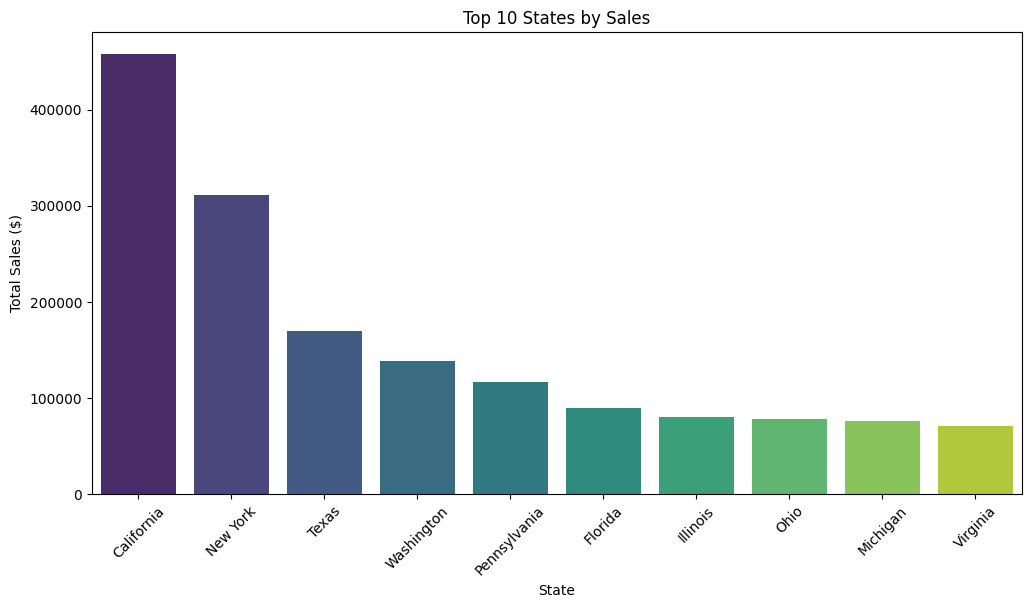

,Sales,Profit
State,,
California,457687.6315,76381.3871
New York,310876.2710,74038.5486


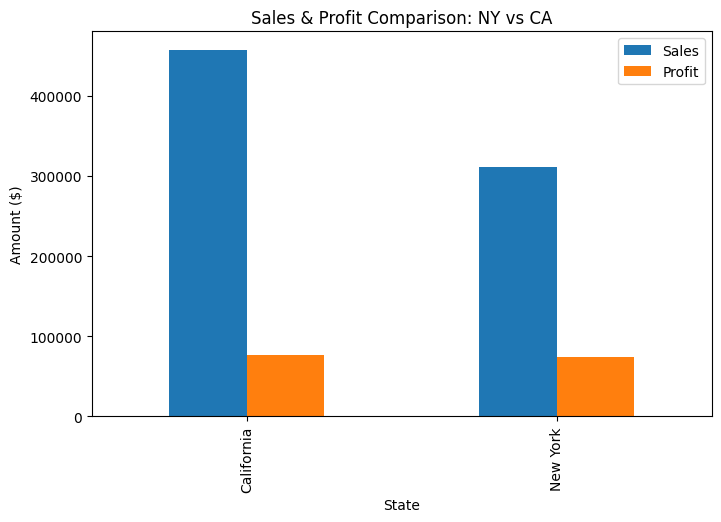

Outstanding Customer in NY: Tom Ashbrook ($13,723.50)


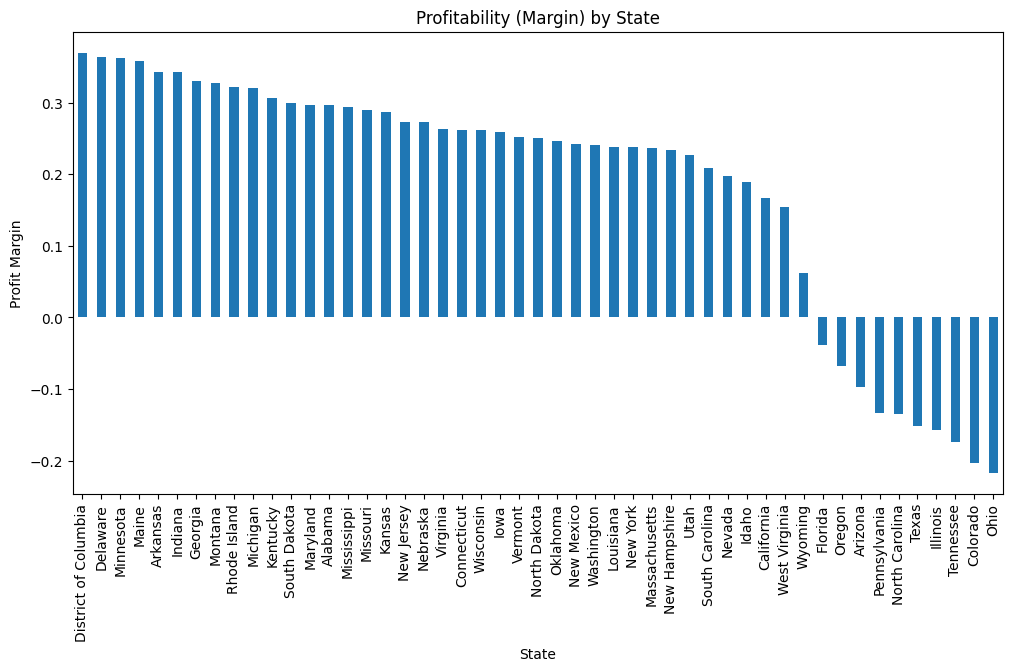

Pareto Check (Profit): Top 20% of customers contribute to 81.43% of profit.


,Sales,Profit
City,,
New York City,256368.1610,62036.9837
Los Angeles,175851.3410,30440.7579
Seattle,119540.7420,29156.0967
San Francisco,112669.0920,17507.3854
Philadelphia,109077.0130,NaN
Houston,64504.7604,NaN
Chicago,48539.5410,NaN
San Diego,47521.0290,6377.1960
Jacksonville,44713.1830,NaN


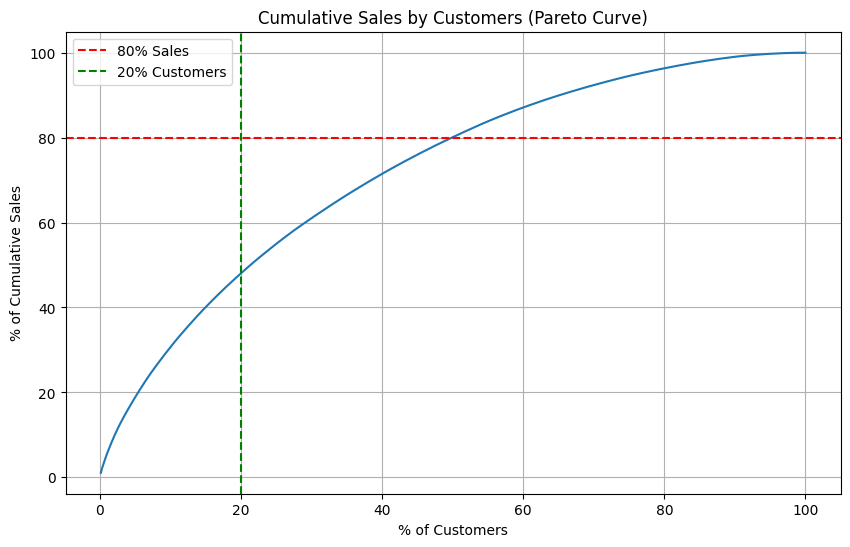

Pareto Check (Sales): Top 20% of customers contribute to 47.96% of sales.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load the dataset
file_path = '/content/US Superstore data (2).xls'
df = pd.read_excel(file_path)

# Preprocessing
df.drop_duplicates(inplace=True)
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# 2. Which states have the most sales?
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=state_sales.index[:10], y=state_sales.values[:10], palette='viridis')
plt.title('Top 10 States by Sales')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.show()

# 3. Difference between NY and CA (Sales and Profit)
ny_ca = df[df['State'].isin(['New York', 'California'])].groupby('State')[['Sales', 'Profit']].sum()
display(ny_ca)
ny_ca.plot(kind='bar', figsize=(8, 5))
plt.title('Sales & Profit Comparison: NY vs CA')
plt.ylabel('Amount ($)')
plt.show()

# 4. Outstanding customer in New York
ny_cust = df[df['State'] == 'New York'].groupby('Customer Name')['Sales'].sum().sort_values(ascending=False)
print(f"Outstanding Customer in NY: {ny_cust.index[0]} (${ny_cust.values[0]:,.2f})")

# 5. Differences among states in profitability (Profit Margin)
state_profitability = (df.groupby('State')['Profit'].sum() / df.groupby('State')['Sales'].sum()).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
state_profitability.plot(kind='bar')
plt.title('Profitability (Margin) by State')
plt.ylabel('Profit Margin')
plt.show()

# 6. Pareto Principle: Customers and Profit
cust_profit = df.groupby('Customer ID')['Profit'].sum().sort_values(ascending=False).reset_index()
cust_profit['cum_profit_perc'] = 100 * cust_profit['Profit'].cumsum() / cust_profit['Profit'].sum()
cust_profit['cust_rank_perc'] = 100 * (cust_profit.index + 1) / len(cust_profit)

pareto_20_profit = cust_profit[cust_profit['cust_rank_perc'] <= 20]['cum_profit_perc'].iloc[-1]
print(f"Pareto Check (Profit): Top 20% of customers contribute to {pareto_20_profit:.2f}% of profit.")

# 7. Top 20 Cities by Sales & Profit
top_20_city_sales = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(20)
top_20_city_profit = df.groupby('City')['Profit'].sum().sort_values(ascending=False).head(20)
display(pd.concat([top_20_city_sales, top_20_city_profit], axis=1, keys=['Sales', 'Profit']).head(20))

# 8. Top 20 customers by Sales
top_20_cust_sales = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(20)

# 9. Cumulative curve in Sales by Customers
cust_sales = df.groupby('Customer ID')['Sales'].sum().sort_values(ascending=False).reset_index()
cust_sales['cum_sales_perc'] = 100 * cust_sales['Sales'].cumsum() / cust_sales['Sales'].sum()
cust_sales['cust_rank_perc'] = 100 * (cust_sales.index + 1) / len(cust_sales)

plt.figure(figsize=(10, 6))
plt.plot(cust_sales['cust_rank_perc'], cust_sales['cum_sales_perc'])
plt.axhline(80, color='r', linestyle='--', label='80% Sales')
plt.axvline(20, color='g', linestyle='--', label='20% Customers')
plt.title('Cumulative Sales by Customers (Pareto Curve)')
plt.xlabel('% of Customers')
plt.ylabel('% of Cumulative Sales')
plt.legend()
plt.grid(True)
plt.show()

pareto_20_sales = cust_sales[cust_sales['cust_rank_perc'] <= 20]['cum_sales_perc'].iloc[-1]
print(f"Pareto Check (Sales): Top 20% of customers contribute to {pareto_20_sales:.2f}% of sales.")